# 📊 Credit Scoring — Notebook 01: Baseline Models (No Tuning)
**Author:** Abu Jafar Sisty  
**Conference:** COMPAS 2026 — IEEE, University of Dhaka  
**Dataset:** Give Me Some Credit — 150,000 records

In [1]:
!pip install -r ../requirements.txt


[notice] A new release of pip is available: 24.3.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os
warnings.filterwarnings('ignore')

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, roc_curve, confusion_matrix
)

SEED = 42
np.random.seed(SEED)

os.makedirs('../figures', exist_ok=True)
os.makedirs('../outputs', exist_ok=True)
os.makedirs('../models', exist_ok=True)
os.makedirs('../data/processed', exist_ok=True)

print('✅ Libraries loaded!')

✅ Libraries loaded!


## 1️⃣ Load Dataset

In [3]:
df = pd.read_csv('../data/raw/cs-training.csv', index_col=0)
print(f'✅ Loaded: {df.shape[0]:,} rows × {df.shape[1]} columns')
print(f'Default rate: {df["SeriousDlqin2yrs"].mean()*100:.2f}%')
df.head(3)

✅ Loaded: 150,000 rows × 11 columns
Default rate: 6.68%


,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
1,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
2,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
3,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0


## 2️⃣ Advanced Data Cleaning

In [4]:
df_clean = df.copy()

# --- Remove extreme outliers in age ---
df_clean = df_clean[(df_clean['age'] >= 18) & (df_clean['age'] <= 100)]

# --- Fix Missing Values ---
df_clean['MonthlyIncome'].fillna(df_clean['MonthlyIncome'].median(), inplace=True)
df_clean['NumberOfDependents'].fillna(0, inplace=True)

# --- Cap Extreme Outliers (Winsorize) ---
# RevolvingUtilization is a ratio, should be 0-1
df_clean['RevolvingUtilizationOfUnsecuredLines'] = df_clean['RevolvingUtilizationOfUnsecuredLines'].clip(0, 1)

# Cap at 99th percentile
for col in ['DebtRatio', 'MonthlyIncome']:
    cap = df_clean[col].quantile(0.99)
    df_clean[col] = df_clean[col].clip(0, cap)

# Cap late payment counts at 10 (anything above is same effect)
for col in ['NumberOfTime30-59DaysPastDueNotWorse',
            'NumberOfTime60-89DaysPastDueNotWorse',
            'NumberOfTimes90DaysLate']:
    df_clean[col] = df_clean[col].clip(0, 10)

print(f'✅ Rows after cleaning: {len(df_clean):,}')
print(f'Missing values remaining: {df_clean.isnull().sum().sum()}')

✅ Rows after cleaning: 149,986
Missing values remaining: 0


## 3️⃣ Advanced Feature Engineering

In [5]:
# --- Combine all late payment features ---
df_clean['TotalTimesPastDue'] = (
    df_clean['NumberOfTime30-59DaysPastDueNotWorse'] +
    df_clean['NumberOfTime60-89DaysPastDueNotWorse'] +
    df_clean['NumberOfTimes90DaysLate']
)

# Weighted late payments (longer delays = worse)
df_clean['WeightedLatePay'] = (
    df_clean['NumberOfTime30-59DaysPastDueNotWorse'] * 1 +
    df_clean['NumberOfTime60-89DaysPastDueNotWorse'] * 2 +
    df_clean['NumberOfTimes90DaysLate'] * 3
)

# --- Income & Debt features ---
df_clean['MonthlyDebt']        = df_clean['DebtRatio'] * df_clean['MonthlyIncome']
df_clean['NetMonthlyIncome']   = df_clean['MonthlyIncome'] - df_clean['MonthlyDebt']
df_clean['IncomePerDependent'] = df_clean['MonthlyIncome'] / (df_clean['NumberOfDependents'] + 1)
df_clean['DebtPerDependent']   = df_clean['MonthlyDebt']   / (df_clean['NumberOfDependents'] + 1)

# --- Credit utilization features ---
df_clean['HighUtilization']    = (df_clean['RevolvingUtilizationOfUnsecuredLines'] > 0.7).astype(int)
df_clean['MaxedOut']           = (df_clean['RevolvingUtilizationOfUnsecuredLines'] > 0.95).astype(int)

# --- Age features ---
df_clean['IsYoung']            = (df_clean['age'] < 30).astype(int)
df_clean['IsSenior']           = (df_clean['age'] > 60).astype(int)
df_clean['AgeBucket']          = pd.cut(df_clean['age'],
                                         bins=[0,25,35,45,55,65,100],
                                         labels=[0,1,2,3,4,5]).astype(int)

# --- Binary flags ---
df_clean['HasLatePay']         = (df_clean['TotalTimesPastDue'] > 0).astype(int)
df_clean['HasSeriousLatePay']  = (df_clean['NumberOfTimes90DaysLate'] > 0).astype(int)
df_clean['HasOpenLoans']       = (df_clean['NumberOfOpenCreditLinesAndLoans'] > 0).astype(int)
df_clean['HasRealEstate']      = (df_clean['NumberRealEstateLoansOrLines'] > 0).astype(int)
df_clean['IsNegativeCash']     = (df_clean['NetMonthlyIncome'] < 0).astype(int)

# --- Interaction features ---
df_clean['UtilizationXLatePay'] = (
    df_clean['RevolvingUtilizationOfUnsecuredLines'] * df_clean['TotalTimesPastDue']
)
df_clean['DebtRatioXAge'] = df_clean['DebtRatio'] * df_clean['age']

print(f'✅ Feature engineering done!')
print(f'Total features: {df_clean.shape[1] - 1}')
print(f'\nNew features:')
original_cols = list(df.columns)
new_cols = [c for c in df_clean.columns if c not in original_cols]
for c in new_cols:
    print(f'   + {c}')

✅ Feature engineering done!
Total features: 28

New features:
   + TotalTimesPastDue
   + WeightedLatePay
   + MonthlyDebt
   + NetMonthlyIncome
   + IncomePerDependent
   + DebtPerDependent
   + HighUtilization
   + MaxedOut
   + IsYoung
   + IsSenior
   + AgeBucket
   + HasLatePay
   + HasSeriousLatePay
   + HasOpenLoans
   + HasRealEstate
   + IsNegativeCash
   + UtilizationXLatePay
   + DebtRatioXAge


## 4️⃣ EDA

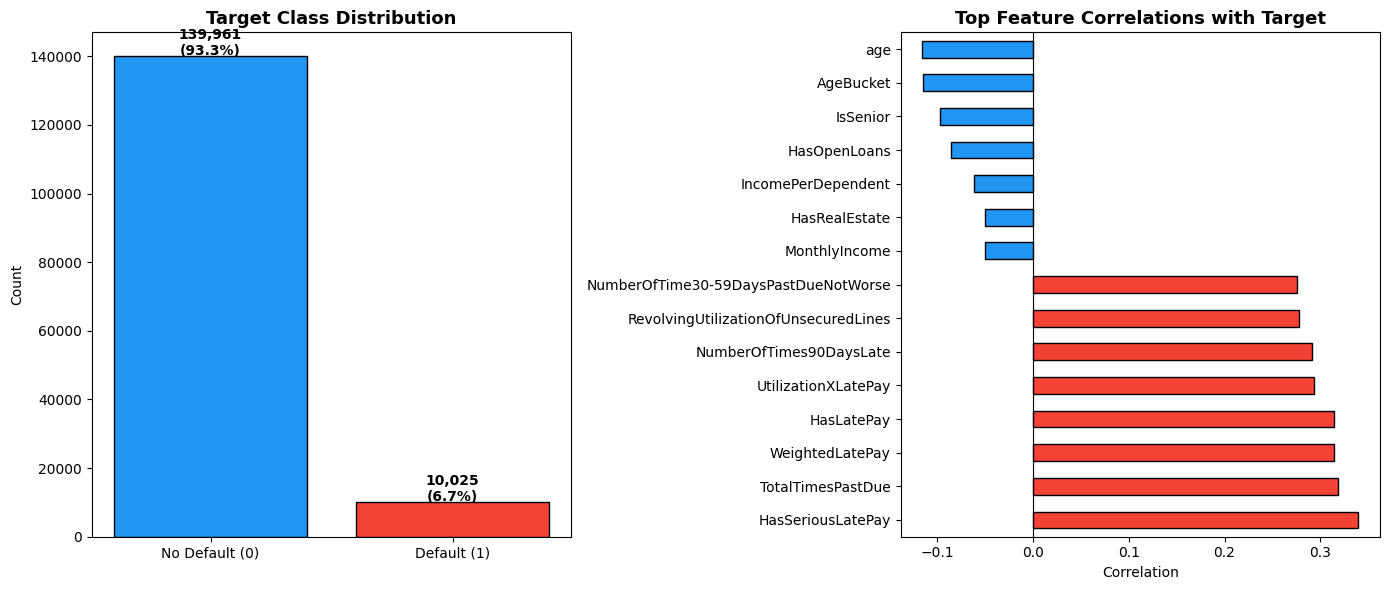

✅ Saved: figures/eda_overview.png


In [6]:
# Correlation with target
target_col = 'SeriousDlqin2yrs'
corr = df_clean.corr(numeric_only=True)[target_col].drop(target_col).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Target distribution
counts = df_clean[target_col].value_counts()
axes[0].bar(['No Default (0)', 'Default (1)'], counts.values,
            color=['#2196F3', '#F44336'], edgecolor='black')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 300, f'{v:,}\n({v/len(df_clean)*100:.1f}%)', ha='center', fontweight='bold')
axes[0].set_title('Target Class Distribution', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Count')

# Top 15 correlations
top_corr = pd.concat([corr.head(8), corr.tail(7)])
colors_c = ['#F44336' if x > 0 else '#2196F3' for x in top_corr]
top_corr.plot(kind='barh', ax=axes[1], color=colors_c, edgecolor='black')
axes[1].set_title('Top Feature Correlations with Target', fontsize=13, fontweight='bold')
axes[1].axvline(x=0, color='black', linewidth=0.8)
axes[1].set_xlabel('Correlation')

plt.tight_layout()
plt.savefig('../figures/eda_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved: figures/eda_overview.png')

## 5️⃣ Train-Test Split

In [7]:
X = df_clean.drop(columns=[target_col])
y = df_clean[target_col]

feature_names = list(X.columns)

X_train, X_test, y_train, y_test = train_test_split(
    X.values, y.values, test_size=0.2, random_state=SEED, stratify=y.values
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

scale_weight = (y.values == 0).sum() / (y.values == 1).sum()

print(f'✅ Features     : {len(feature_names)}')
print(f'Train size     : {X_train.shape[0]:,}')
print(f'Test size      : {X_test.shape[0]:,}')
print(f'Default rate   : {y.mean()*100:.2f}%')
print(f'scale_pos_weight: {scale_weight:.2f}')

import json
with open('../models/feature_names.json', 'w') as f:
    json.dump(feature_names, f)
print('✅ Feature names saved!')

✅ Features     : 28
Train size     : 119,988
Test size      : 29,998
Default rate   : 6.68%
scale_pos_weight: 13.96
✅ Feature names saved!


## 6️⃣ Train 4 Baseline Models

In [8]:
models = {
    'Logistic Regression': LogisticRegression(
        random_state=SEED, max_iter=1000, class_weight='balanced'
    ),
    'Random Forest': RandomForestClassifier(
        random_state=SEED, class_weight='balanced', n_jobs=-1
    ),
    'Gradient Boosting': GradientBoostingClassifier(
        random_state=SEED
    ),
    'XGBoost': XGBClassifier(
        random_state=SEED, eval_metric='logloss',
        verbosity=0, scale_pos_weight=scale_weight,
        n_jobs=-1
    )
}

results = []

for name, model in models.items():
    print(f'\n🔄 Training: {name} ...')

    X_tr = X_train_scaled if name == 'Logistic Regression' else X_train
    X_te = X_test_scaled  if name == 'Logistic Regression' else X_test

    model.fit(X_tr, y_train)
    y_pred = model.predict(X_te)
    y_prob = model.predict_proba(X_te)[:, 1]

    results.append({
        'Model':     name,
        'AUC':       round(roc_auc_score(y_test, y_prob), 4),
        'Accuracy':  round(accuracy_score(y_test, y_pred), 4),
        'Precision': round(precision_score(y_test, y_pred, average='weighted', zero_division=0), 4),
        'Recall':    round(recall_score(y_test, y_pred, average='weighted'), 4),
        'F1-Score':  round(f1_score(y_test, y_pred, average='weighted'), 4)
    })
    print(f'   ✅ AUC: {results[-1]["AUC"]:.4f} | Acc: {results[-1]["Accuracy"]:.4f} | F1: {results[-1]["F1-Score"]:.4f}')

results_df = pd.DataFrame(results).sort_values('AUC', ascending=False)
results_df.to_csv('../outputs/baseline_results.csv', index=False)

print('\n===== BASELINE RESULTS =====')
print(results_df.to_string(index=False))
print('\n✅ Saved: outputs/baseline_results.csv')


🔄 Training: Logistic Regression ...
   ✅ AUC: 0.8678 | Acc: 0.7855 | F1: 0.8361

🔄 Training: Random Forest ...
   ✅ AUC: 0.8427 | Acc: 0.9353 | F1: 0.9185

🔄 Training: Gradient Boosting ...
   ✅ AUC: 0.8709 | Acc: 0.9375 | F1: 0.9218

🔄 Training: XGBoost ...
   ✅ AUC: 0.8503 | Acc: 0.8339 | F1: 0.8680

===== BASELINE RESULTS =====
              Model    AUC  Accuracy  Precision  Recall  F1-Score
  Gradient Boosting 0.8709    0.9375     0.9219  0.9375    0.9218
Logistic Regression 0.8678    0.7855     0.9301  0.7855    0.8361
            XGBoost 0.8503    0.8339     0.9252  0.8339    0.8680
      Random Forest 0.8427    0.9353     0.9169  0.9353    0.9185

✅ Saved: outputs/baseline_results.csv


## 7️⃣ AUC Bar Chart

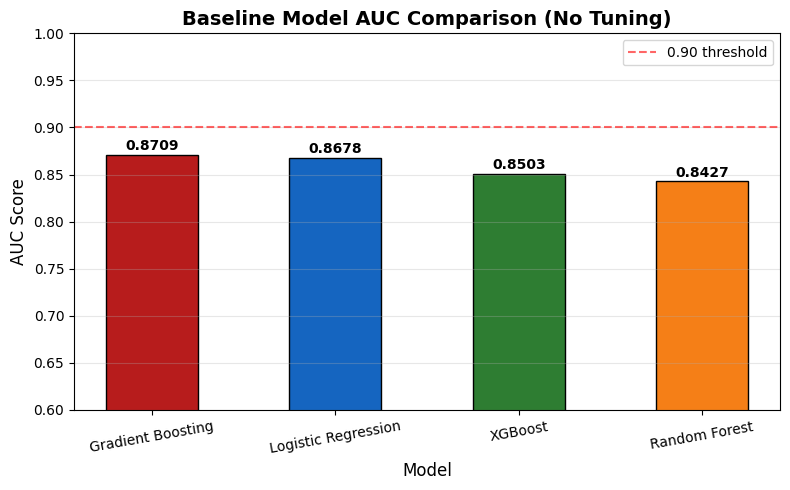

✅ Saved: figures/baseline_auc.png


In [9]:
fig, ax = plt.subplots(figsize=(8, 5))
colors = ['#B71C1C', '#1565C0', '#2E7D32', '#F57F17']
bars = ax.bar(results_df['Model'], results_df['AUC'], color=colors, edgecolor='black', width=0.5)
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
            f'{bar.get_height():.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
ax.set_ylim(0.6, 1.0)
ax.set_title('Baseline Model AUC Comparison (No Tuning)', fontsize=14, fontweight='bold')
ax.set_xlabel('Model', fontsize=12)
ax.set_ylabel('AUC Score', fontsize=12)
ax.tick_params(axis='x', rotation=10)
ax.axhline(y=0.90, color='red', linestyle='--', alpha=0.6, label='0.90 threshold')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('../figures/baseline_auc.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved: figures/baseline_auc.png')

## 8️⃣ ROC-AUC Curve

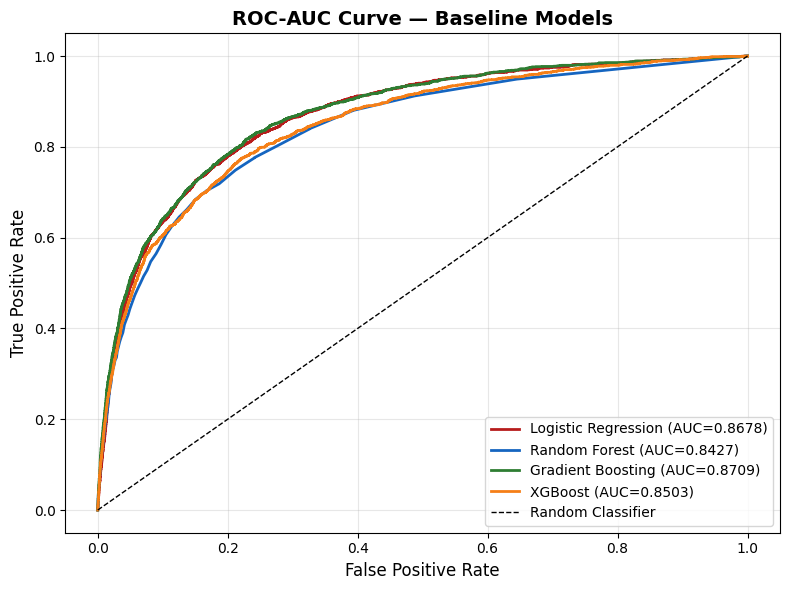

✅ Saved: figures/baseline_roc_curve.png


In [10]:
fig, ax = plt.subplots(figsize=(8, 6))
colors_roc = ['#B71C1C', '#1565C0', '#2E7D32', '#F57F17']

for (name, model), color in zip(models.items(), colors_roc):
    X_te = X_test_scaled if name == 'Logistic Regression' else X_test
    y_prob = model.predict_proba(X_te)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc_val = roc_auc_score(y_test, y_prob)
    ax.plot(fpr, tpr, label=f'{name} (AUC={auc_val:.4f})', color=color, linewidth=2)

ax.plot([0,1],[0,1],'k--', linewidth=1, label='Random Classifier')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC-AUC Curve — Baseline Models', fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=10)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('../figures/baseline_roc_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved: figures/baseline_roc_curve.png')

## 9️⃣ Confusion Matrix (Best Model)

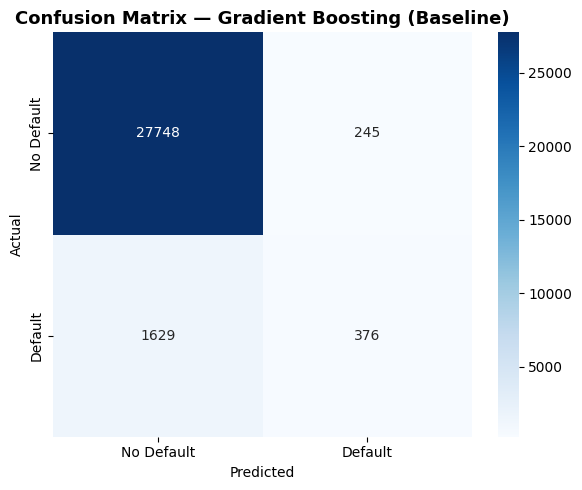

✅ Saved: figures/baseline_confusion_matrix.png


In [11]:
best_name  = results_df.iloc[0]['Model']
best_model = models[best_name]
X_te_best  = X_test_scaled if best_name == 'Logistic Regression' else X_test
y_pred_best = best_model.predict(X_te_best)

cm = confusion_matrix(y_test, y_pred_best)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['No Default', 'Default'],
            yticklabels=['No Default', 'Default'])
ax.set_title(f'Confusion Matrix — {best_name} (Baseline)', fontsize=13, fontweight='bold')
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
plt.tight_layout()
plt.savefig('../figures/baseline_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved: figures/baseline_confusion_matrix.png')

## 🔟 Final Summary

In [12]:
print('='*60)
print('      NOTEBOOK 01 COMPLETE — BASELINE RESULTS')
print('='*60)
print(results_df.to_string(index=False))
print('='*60)
print(f'\n🏆 Best Baseline Model : {results_df.iloc[0]["Model"]}')
print(f'   AUC                 : {results_df.iloc[0]["AUC"]}')
print(f'   F1-Score            : {results_df.iloc[0]["F1-Score"]}')
print('\n➡️  Next: Run 02_with_tuning.ipynb')

      NOTEBOOK 01 COMPLETE — BASELINE RESULTS
              Model    AUC  Accuracy  Precision  Recall  F1-Score
  Gradient Boosting 0.8709    0.9375     0.9219  0.9375    0.9218
Logistic Regression 0.8678    0.7855     0.9301  0.7855    0.8361
            XGBoost 0.8503    0.8339     0.9252  0.8339    0.8680
      Random Forest 0.8427    0.9353     0.9169  0.9353    0.9185

🏆 Best Baseline Model : Gradient Boosting
   AUC                 : 0.8709
   F1-Score            : 0.9218

➡️  Next: Run 02_with_tuning.ipynb


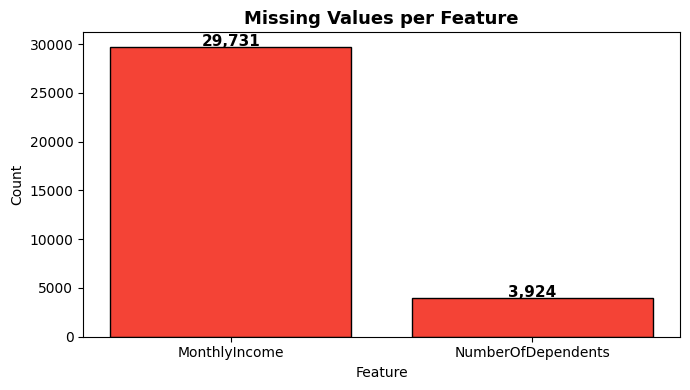

Saved!


In [1]:
import matplotlib.pyplot as plt
import pandas as pd

df = pd.read_csv('../data/raw/cs-training.csv', index_col=0)

missing = df.isnull().sum()
missing = missing[missing > 0]

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(missing.index, missing.values, color='#F44336', edgecolor='black')
for bar, val in zip(bars, missing.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
            f'{val:,}', ha='center', fontsize=11, fontweight='bold')
ax.set_title('Missing Values per Feature', fontsize=13, fontweight='bold')
ax.set_ylabel('Count')
ax.set_xlabel('Feature')
plt.tight_layout()
plt.savefig('../figures/missing_values.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved!')